In [112]:
import os
import numpy as np
import pandas as pd
import gc
import time
from contextlib import contextmanager
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, PolynomialFeatures, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import zipfile 
from pathlib import Path

import missingno as msno

In [113]:
zip_path = Path("C:\\Users\\chris\\Initiez_vous_au_ML_Ops\\Projet+Mise+en+prod+-+home-credit-default-risk.zip")
extract_dir = Path("data")

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_dir)

print("Extraction terminée !")

Extraction terminée !


In [114]:
print(os.listdir("data"))

['application_test.csv', 'application_train.csv', 'bureau.csv', 'bureau_balance.csv', 'credit_card_balance.csv', 'HomeCredit_columns_description.csv', 'installments_payments.csv', 'POS_CASH_balance.csv', 'previous_application.csv', 'sample_submission.csv']


In [115]:
# on regarde le fichier previous_application (clé commune SK_ID_PREV avec credit_card_balance et installments_payments)
previous_application = pd.read_csv(r"C:\Users\chris\Initiez_vous_au_ML_Ops\data\previous_application.csv")
previous_application.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: >

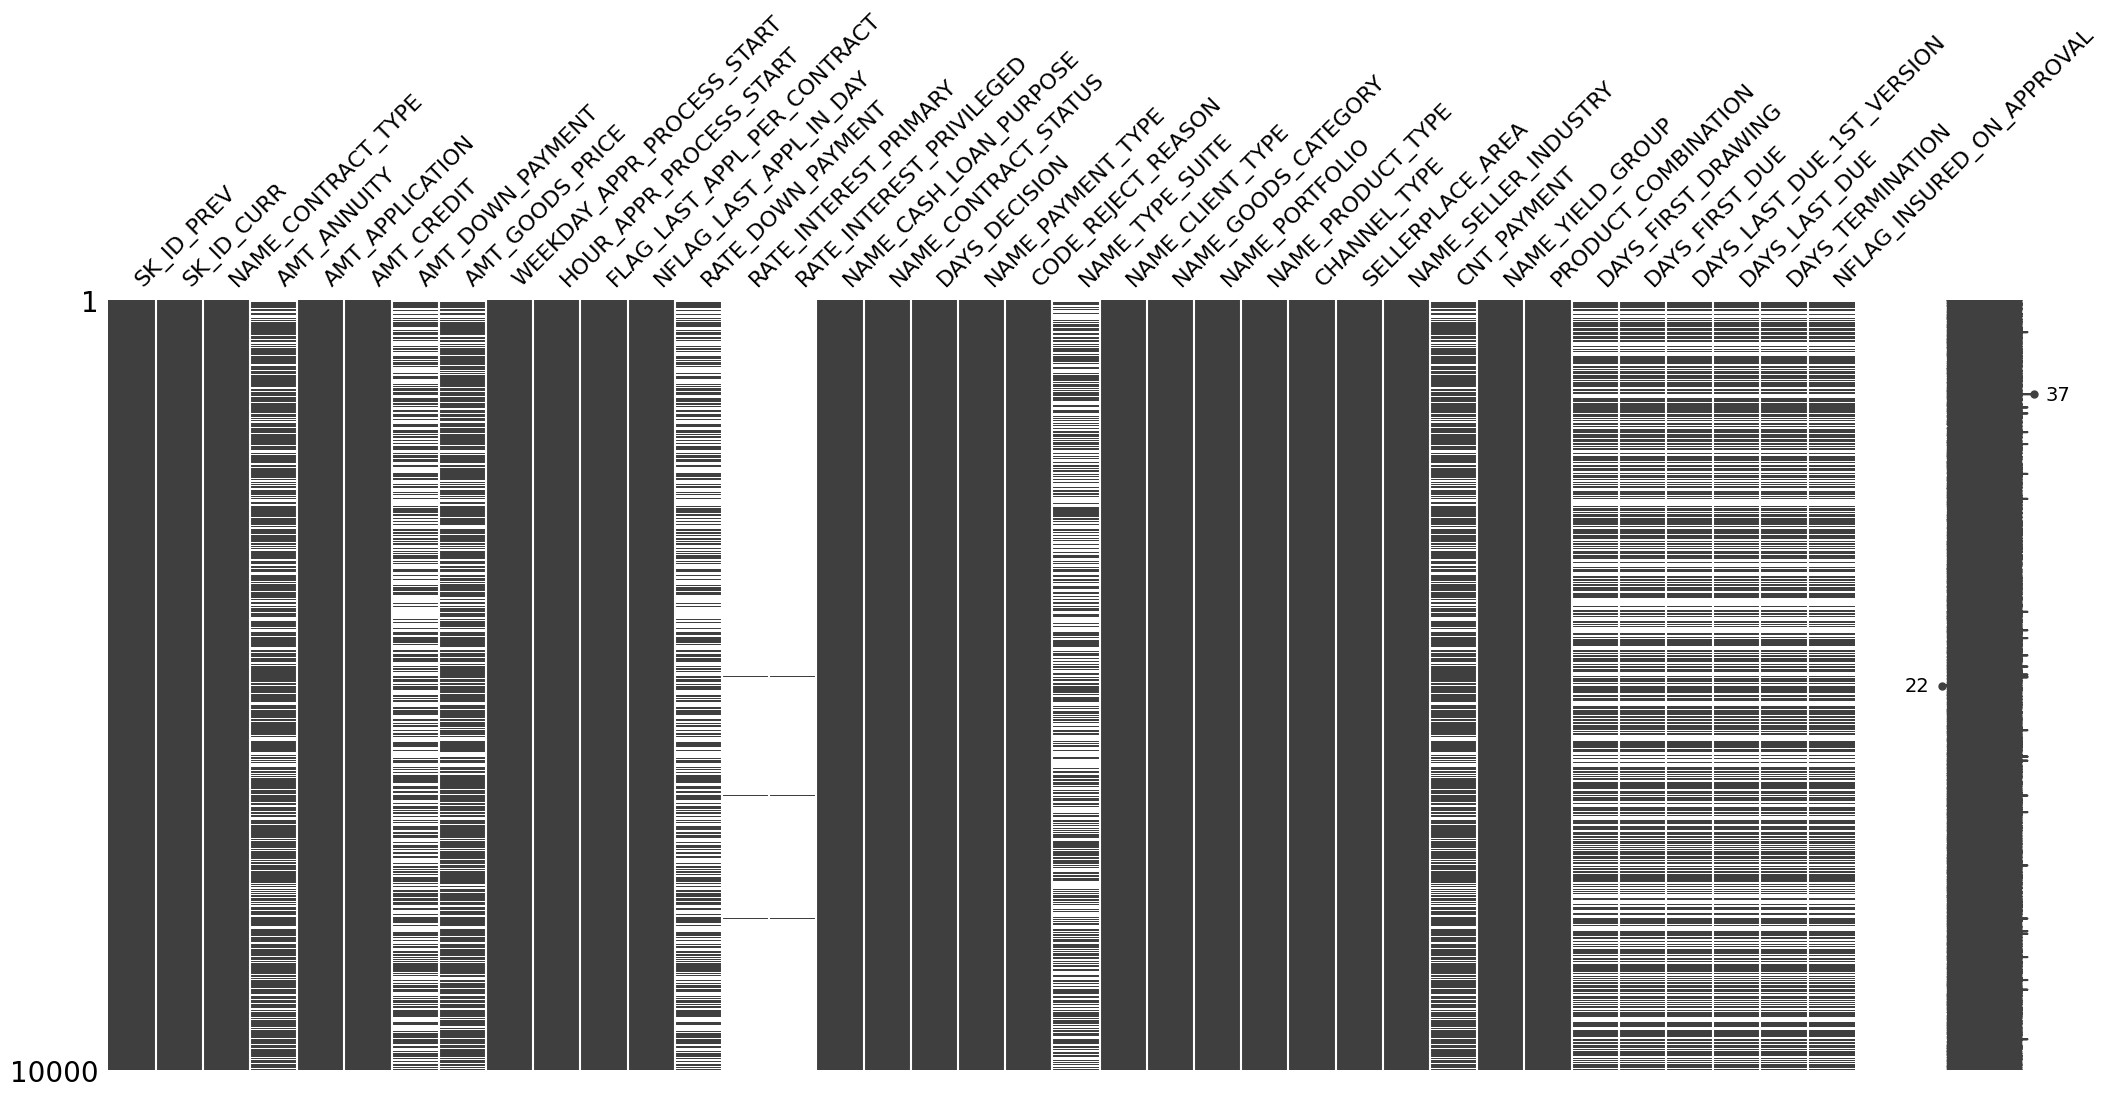

In [116]:
%matplotlib inline
msno.matrix(previous_application.sample(10000))

In [117]:
previous_application.duplicated().sum()

np.int64(0)

In [118]:
previous_application.describe()

,SK_ID_PREV,SK_ID_CURR,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,HOUR_APPR_PROCESS_START,NFLAG_LAST_APPL_IN_DAY,RATE_DOWN_PAYMENT,...,RATE_INTEREST_PRIVILEGED,DAYS_DECISION,SELLERPLACE_AREA,CNT_PAYMENT,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
count,1.670214e+06,1.670214e+06,1.297979e+06,1.670214e+06,1.670213e+06,7.743700e+05,1.284699e+06,1.670214e+06,1.670214e+06,774370.000000,...,5951.000000,1.670214e+06,1.670214e+06,1.297984e+06,997149.000000,997149.000000,997149.000000,997149.000000,997149.000000,997149.000000
mean,1.923089e+06,2.783572e+05,1.595512e+04,1.752339e+05,1.961140e+05,6.697402e+03,2.278473e+05,1.248418e+01,9.964675e-01,0.079637,...,0.773503,-8.806797e+02,3.139511e+02,1.605408e+01,342209.855039,13826.269337,33767.774054,76582.403064,81992.343838,0.332570
std,5.325980e+05,1.028148e+05,1.478214e+04,2.927798e+05,3.185746e+05,2.092150e+04,3.153966e+05,3.334028e+00,5.932963e-02,0.107823,...,0.100879,7.790997e+02,7.127443e+03,1.456729e+01,88916.115833,72444.869708,106857.034789,149647.415123,153303.516729,0.471134
min,1.000001e+06,1.000010e+05,0.000000e+00,0.000000e+00,0.000000e+00,-9.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,-0.000015,...,0.373150,-2.922000e+03,-1.000000e+00,0.000000e+00,-2922.000000,-2892.000000,-2801.000000,-2889.000000,-2874.000000,0.000000
25%,1.461857e+06,1.893290e+05,6.321780e+03,1.872000e+04,2.416050e+04,0.000000e+00,5.084100e+04,1.000000e+01,1.000000e+00,0.000000,...,0.715645,-1.300000e+03,-1.000000e+00,6.000000e+00,365243.000000,-1628.000000,-1242.000000,-1314.000000,-1270.000000,0.000000
50%,1.923110e+06,2.787145e+05,1.125000e+04,7.104600e+04,8.054100e+04,1.638000e+03,1.123200e+05,1.200000e+01,1.000000e+00,0.051605,...,0.835095,-5.810000e+02,3.000000e+00,1.200000e+01,365243.000000,-831.000000,-361.000000,-537.000000,-499.000000,0.000000
75%,2.384280e+06,3.675140e+05,2.065842e+04,1.803600e+05,2.164185e+05,7.740000e+03,2.340000e+05,1.500000e+01,1.000000e+00,0.108909,...,0.852537,-2.800000e+02,8.200000e+01,2.400000e+01,365243.000000,-411.000000,129.000000,-74.000000,-44.000000,1.000000
max,2.845382e+06,4.562550e+05,4.180581e+05,6.905160e+06,6.905160e+06,3.060045e+06,6.905160e+06,2.300000e+01,1.000000e+00,1.000000,...,1.000000,-1.000000e+00,4.000000e+06,8.400000e+01,365243.000000,365243.000000,365243.000000,365243.000000,365243.000000,1.000000


In [119]:
previous_application.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670214 entries, 0 to 1670213
Data columns (total 37 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1670214 non-null  int64  
 1   SK_ID_CURR                   1670214 non-null  int64  
 2   NAME_CONTRACT_TYPE           1670214 non-null  object 
 3   AMT_ANNUITY                  1297979 non-null  float64
 4   AMT_APPLICATION              1670214 non-null  float64
 5   AMT_CREDIT                   1670213 non-null  float64
 6   AMT_DOWN_PAYMENT             774370 non-null   float64
 7   AMT_GOODS_PRICE              1284699 non-null  float64
 8   WEEKDAY_APPR_PROCESS_START   1670214 non-null  object 
 9   HOUR_APPR_PROCESS_START      1670214 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1670214 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY       1670214 non-null  int64  
 12  RATE_DOWN_PAYMENT            774370 non-nu

In [120]:
previous_application['NAME_CONTRACT_TYPE'].value_counts();

In [121]:
previous_application['WEEKDAY_APPR_PROCESS_START'].value_counts();

In [122]:
previous_application['FLAG_LAST_APPL_PER_CONTRACT'].value_counts();

In [123]:
previous_application['HOUR_APPR_PROCESS_START'].value_counts();

In [124]:
previous_application['NFLAG_LAST_APPL_IN_DAY'].value_counts();

In [125]:
previous_application['NFLAG_INSURED_ON_APPROVAL'].value_counts()

NFLAG_INSURED_ON_APPROVAL
0.0    665527
1.0    331622
Name: count, dtype: int64

In [126]:
previous_application['NAME_TYPE_SUITE'].value_counts()

NAME_TYPE_SUITE
Unaccompanied      508970
Family             213263
Spouse, partner     67069
Children            31566
Other_B             17624
Other_A              9077
Group of people      2240
Name: count, dtype: int64

In [127]:
previous_application['NAME_TYPE_SUITE'].isna().sum()

np.int64(820405)

In [128]:
previous_application['NAME_CLIENT_TYPE'].value_counts();

In [129]:
previous_application['NAME_GOODS_CATEGORY'].value_counts();

In [130]:
previous_application['NAME_PORTFOLIO'].value_counts();

In [131]:
previous_application['NAME_PORTFOLIO'].isna().sum()

np.int64(0)

In [132]:
previous_application['NAME_PRODUCT_TYPE'].value_counts();

In [133]:
previous_application['CHANNEL_TYPE'].value_counts();

In [134]:
previous_application['SELLERPLACE_AREA'].value_counts();

In [135]:
previous_application['AMT_DOWN_PAYMENT'].value_counts();

In [136]:
previous_application['RATE_DOWN_PAYMENT'].value_counts();

In [137]:
previous_application['RATE_INTEREST_PRIMARY'].value_counts();

In [138]:
previous_application['RATE_INTEREST_PRIMARY'].isna().sum()

np.int64(1664263)

In [139]:
previous_application['RATE_INTEREST_PRIVILEGED'].value_counts();

In [140]:
previous_application['RATE_INTEREST_PRIVILEGED'].isnull().sum()

np.int64(1664263)

In [141]:
# Traitement des NaN AVANT encodage
previous_application = previous_application.copy()

# Imputation par 0 des colonnes avec un peu de NaN
amount_cols = ['AMT_ANNUITY', 'AMT_DOWN_PAYMENT', 'AMT_GOODS_PRICE','RATE_DOWN_PAYMENT']
for col in amount_cols:
    if col in previous_application.columns:
        previous_application[col].fillna(0, inplace=True)


# CNT_PAYMENT: on remplace les NaN par la médiane plutôt que zéro
if 'CNT_PAYMENT' in previous_application.columns:
    previous_application['CNT_PAYMENT'].fillna(previous_application['CNT_PAYMENT'].median(), inplace=True)        

# Imputation des jours par la médiane
days_cols = [col for col in previous_application.columns if 'DAYS_' in col]
for col in days_cols:
    if col in previous_application.columns:
        previous_application[col].fillna(previous_application[col].median(), inplace=True)

# Imputation des catégorielles par 'Unknown'
cat_cols = previous_application.select_dtypes(include=['object']).columns
for col in cat_cols:
    if col != 'SK_ID_CURR':  # Ne pas toucher à l'identifiant
        previous_application[col].fillna('Unknown', inplace=True)

In [142]:
# visibilité des colonnes constantes (à plus de 90%) 
def get_constant_cols(df, threshold=0.90):
    constant = []
    for col in df.select_dtypes(include=[np.number]).columns:
        if col == 'SK_ID_CURR':
            continue
        most_common = df[col].value_counts(normalize=True).iloc[0] if len(df[col].value_counts()) > 0 else 0
        if most_common > threshold:
            constant.append(col)
    return constant

cols_constant = get_constant_cols(previous_application, threshold=0.90)
print("Colonnes constantes à plus de 90% : ", cols_constant)

Colonnes constantes à plus de 90% :  ['NFLAG_LAST_APPL_IN_DAY', 'DAYS_FIRST_DRAWING']


In [143]:
previous_application.drop(columns=['RATE_INTEREST_PRIMARY', 'RATE_INTEREST_PRIVILEGED'
                                   ,'WEEKDAY_APPR_PROCESS_START','WEEKDAY_APPR_PROCESS_START'
                                   ,'HOUR_APPR_PROCESS_START','FLAG_LAST_APPL_PER_CONTRACT'
                                   ,'NAME_CLIENT_TYPE','NAME_GOODS_CATEGORY','NAME_PORTFOLIO'
                                   ,'NAME_PRODUCT_TYPE','CHANNEL_TYPE','NFLAG_LAST_APPL_IN_DAY','DAYS_FIRST_DRAWING'
                                   ]
                          , inplace=True)

In [144]:
# Vérifier les colonnes non-numériques
print(previous_application.select_dtypes(exclude=['number']).columns)

Index(['NAME_CONTRACT_TYPE', 'NAME_CASH_LOAN_PURPOSE', 'NAME_CONTRACT_STATUS',
       'NAME_PAYMENT_TYPE', 'CODE_REJECT_REASON', 'NAME_TYPE_SUITE',
       'NAME_SELLER_INDUSTRY', 'NAME_YIELD_GROUP', 'PRODUCT_COMBINATION'],
      dtype='object')


In [145]:
# Séparer les colonnes numériques et catégorielles
num_cols = previous_application.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('SK_ID_CURR')  # Retirer l'identifiant

cat_cols = previous_application.select_dtypes(include=['object']).columns.tolist()

In [146]:
# One-Hot Encoding
prev_encoded = previous_application[['SK_ID_CURR'] + num_cols].copy()
prev_cat_encoded = pd.get_dummies(previous_application[cat_cols], drop_first=True)
prev_encoded = pd.concat([prev_encoded, prev_cat_encoded], axis=1)

In [147]:
# Agrégations
agg_dict = {}

# Pour les colonnes numériques originales : mean, min, max, sum
for col in num_cols:
    agg_dict[col] = ['mean', 'min', 'max', 'sum']

# Pour les colonnes one-hot encodées : mean (proportion) et sum (count)
for col in prev_cat_encoded.columns:
    agg_dict[col] = ['mean', 'sum']  # mean = proportion, sum = nombre d'occurrences

# Agrégation
prev_agg = prev_encoded.groupby('SK_ID_CURR').agg(agg_dict)


In [148]:
# Renommage des colonnes
prev_agg.columns = ['PREV_' + '_'.join(col).upper() for col in prev_agg.columns]
prev_agg.reset_index(inplace=True)

print(f"Shape finale: {prev_agg.shape}")
prev_agg.head()

Shape finale: (338857, 219)


C:\Users\chris\AppData\Local\Temp\ipykernel_7000\335642412.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  prev_agg.reset_index(inplace=True)


,SK_ID_CURR,PREV_SK_ID_PREV_MEAN,PREV_SK_ID_PREV_MIN,PREV_SK_ID_PREV_MAX,PREV_SK_ID_PREV_SUM,PREV_AMT_ANNUITY_MEAN,PREV_AMT_ANNUITY_MIN,PREV_AMT_ANNUITY_MAX,PREV_AMT_ANNUITY_SUM,PREV_AMT_APPLICATION_MEAN,...,PREV_PRODUCT_COMBINATION_POS MOBILE WITH INTEREST_MEAN,PREV_PRODUCT_COMBINATION_POS MOBILE WITH INTEREST_SUM,PREV_PRODUCT_COMBINATION_POS MOBILE WITHOUT INTEREST_MEAN,PREV_PRODUCT_COMBINATION_POS MOBILE WITHOUT INTEREST_SUM,PREV_PRODUCT_COMBINATION_POS OTHER WITH INTEREST_MEAN,PREV_PRODUCT_COMBINATION_POS OTHER WITH INTEREST_SUM,PREV_PRODUCT_COMBINATION_POS OTHERS WITHOUT INTEREST_MEAN,PREV_PRODUCT_COMBINATION_POS OTHERS WITHOUT INTEREST_SUM,PREV_PRODUCT_COMBINATION_UNKNOWN_MEAN,PREV_PRODUCT_COMBINATION_UNKNOWN_SUM
0,100001,1.369693e+06,1369693,1369693,1369693,3951.000,3951.000,3951.000,3951.000,24835.50,...,1.0,1,0.0,0,0.0,0,0.0,0,0.0,0
1,100002,1.038818e+06,1038818,1038818,1038818,9251.775,9251.775,9251.775,9251.775,179055.00,...,0.0,0,0.0,0,1.0,1,0.0,0,0.0,0
2,100003,2.281150e+06,1810518,2636178,6843451,56553.990,6737.310,98356.995,169661.970,435436.50,...,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0
3,100004,1.564014e+06,1564014,1564014,1564014,5357.250,5357.250,5357.250,5357.250,24282.00,...,0.0,0,1.0,1,0.0,0,0.0,0,0.0,0
4,100005,2.176837e+06,1857999,2495675,4353674,2406.600,0.000,4813.200,4813.200,22308.75,...,0.5,1,0.0,0,0.0,0,0.0,0,0.0,0


In [ ]:
prev_agg.columns.tolist()

In [ ]:
# N.B: Merger au niveau CLIENT dans application_train
# train = train.merge(prev_agg, on='SK_ID_CURR', how='left')